# Replikasi Eksperimen Giudici et al. (2020)
## Network Models to Improve Automated Cryptocurrency Portfolio Management

Notebook ini membandingkan strategi portofolio kripto:
1. **EW** — Equally Weighted (1/N)
2. **CM** — Classical Markowitz
3. **GM** — Glasso Markowitz
4. **NW (γ=0)** — Network Markowitz (RMT+MST murni)
5. **NW (γ=1.0)** — Network Markowitz (dengan penalti sentralitas eigenvector)
6. **AGGP v4** — Adaptive Graph-Gated Portfolio (Model Usulan)

---
## Sel 1 — Persiapan Library

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.linalg import eigh
from sklearn.covariance import GraphicalLassoCV
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Sel 2 — Memuat Data

Memuat data return dan harga dari file Excel. Fokus pada dataset return harian untuk 10 aset kripto utama, periode **14 September 2017 – 17 Oktober 2019**.

In [52]:
# Load data
excel_file = 'crypto_data_real.xlsx'
df_returns = pd.read_excel(excel_file, sheet_name='Returns', index_col=0)
df_prices  = pd.read_excel(excel_file, sheet_name='Prices',  index_col=0)

crypto_names = df_returns.columns.tolist()
n_assets     = len(crypto_names)

print(f"Data loaded: {df_returns.shape[0]} days, {n_assets} assets")
print(f"Period: {df_returns.index[0]} to {df_returns.index[-1]}")
print(f"Assets: {crypto_names}")

Data loaded: 763 days, 10 assets
Period: 2017-09-15 00:00:00 to 2019-10-17 00:00:00
Assets: ['BTC', 'ETH', 'XRP', 'USDT', 'BCH', 'LTC', 'BNB', 'EOS', 'XLM', 'TRX']


---
## Sel 3 — Statistik Ringkasan (Table 1)

Tabel statistik deskriptif: Mean, Standar Deviasi, Kurtosis, dan Skewness.

In [53]:
# Create summary statistics table
summary_stats = pd.DataFrame({
    'Mean':     df_returns.mean(),
    'Std':      df_returns.std(),
    'Kurtosis': df_returns.kurt(),
    'Skewness': df_returns.skew()
})

print("TABLE 1 | Summary statistics.")
print(summary_stats.round(4))

TABLE 1 | Summary statistics.
        Mean     Std  Kurtosis  Skewness
BTC   0.0012  0.0434    3.0822    0.0523
ETH  -0.0008  0.0507    2.8209   -0.2916
XRP   0.0004  0.0654   18.9009    2.0588
USDT -0.0000  0.0057   21.7209    0.7437
BCH  -0.0014  0.0724    7.5671    0.6231
LTC   0.0004  0.0585    6.6357    1.0988
BNB   0.0029  0.0621   10.2612    1.0694
EOS   0.0012  0.0709    4.7582    0.5781
XLM   0.0006  0.0657    7.0332    0.9799
TRX   0.0025  0.0879   22.1856    2.6905


---
## Sel 4 — Visualisasi Harga Ternormalisasi (Figure 1 & 2)

Harga awal setiap aset dinormalisasi menjadi 100 pada tanggal **7 Januari 2018**.

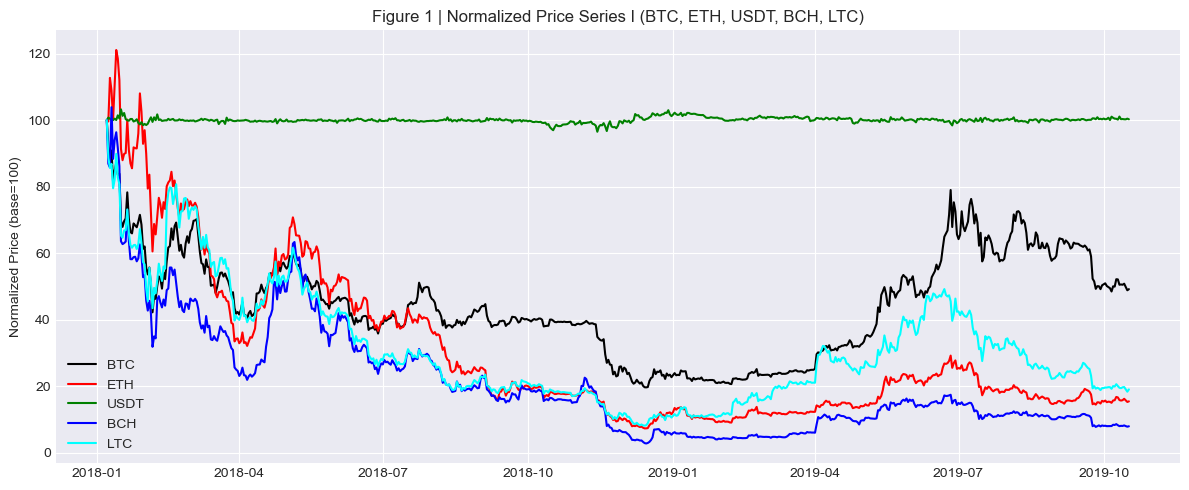

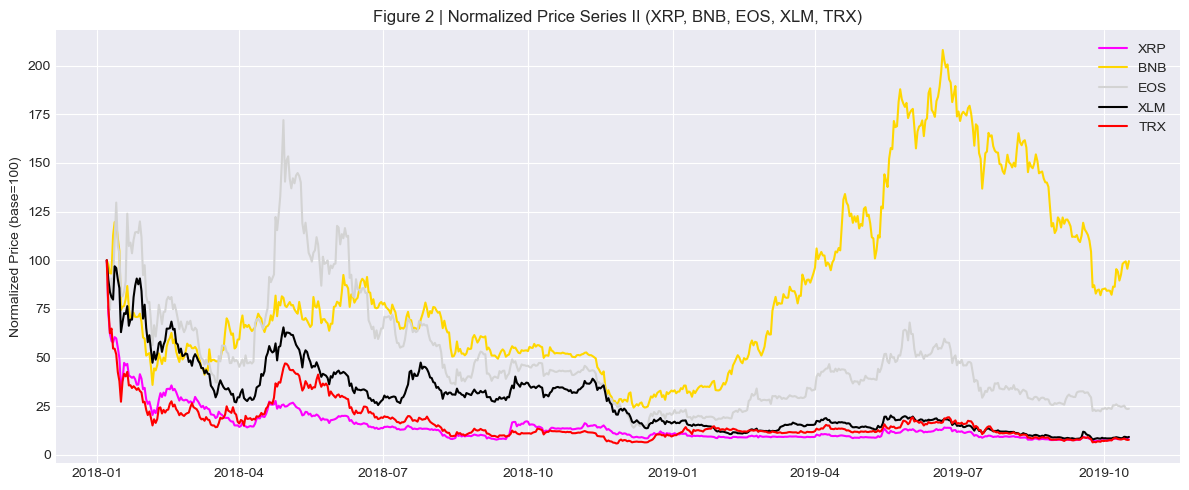

In [54]:
# --- Figure 1: BTC, ETH, USDT, BCH, LTC ---
assets_1  = ['BTC', 'ETH', 'USDT', 'BCH', 'LTC']
df_norm_1 = (df_prices.loc['2018-01-07':, assets_1] / df_prices.loc['2018-01-07', assets_1]) * 100
colors_1  = ['black', 'red', 'green', 'blue', 'cyan']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_1.columns):
    plt.plot(df_norm_1.index, df_norm_1[col], label=col, color=colors_1[i])
plt.title('Figure 1 | Normalized Price Series I (BTC, ETH, USDT, BCH, LTC)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

# --- Figure 2: XRP, BNB, EOS, XLM, TRX ---
assets_2  = ['XRP', 'BNB', 'EOS', 'XLM', 'TRX']
df_norm_2 = (df_prices.loc['2018-01-07':, assets_2] / df_prices.loc['2018-01-07', assets_2]) * 100
colors_2  = ['magenta', 'gold', 'lightgrey', 'black', 'red']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_2.columns):
    plt.plot(df_norm_2.index, df_norm_2[col], label=col, color=colors_2[i])
plt.title('Figure 2 | Normalized Price Series II (XRP, BNB, EOS, XLM, TRX)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

---
## Sel 5 — Visualisasi Minimum Spanning Tree (Figure 3 & 4)

Mereplikasi Figure 3 & 4 dari paper: struktur jaringan MST aset kripto pada periode gelembung spekulatif dan periode stabil.

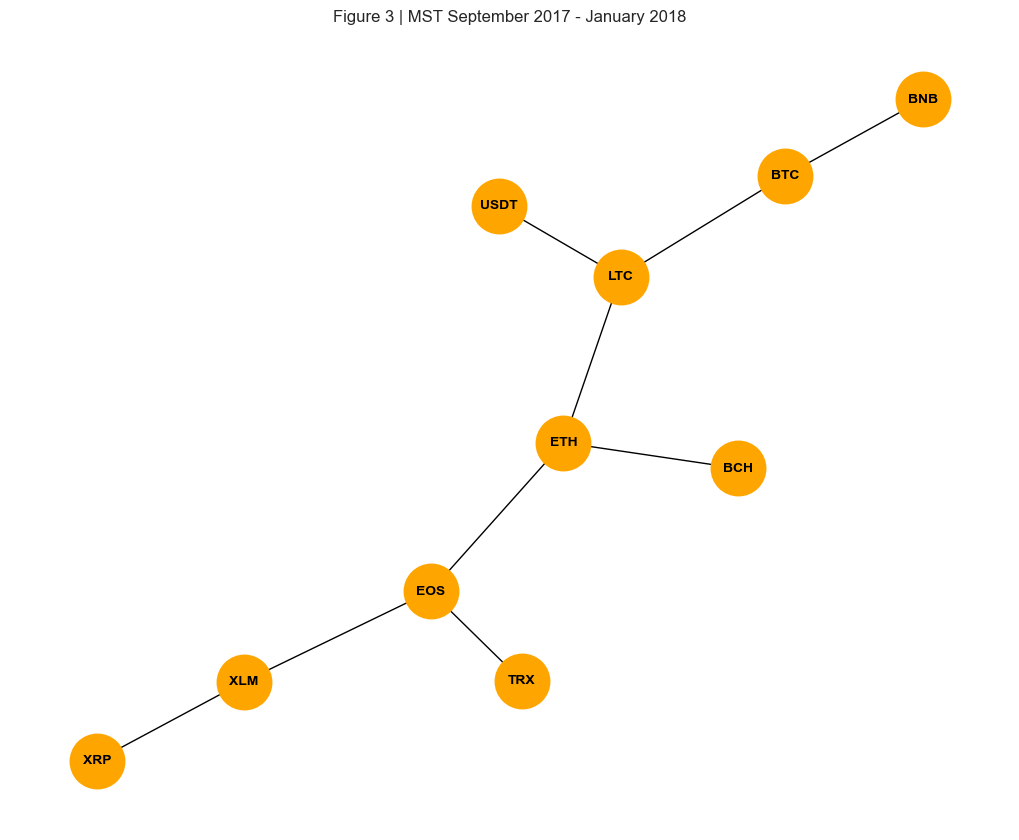

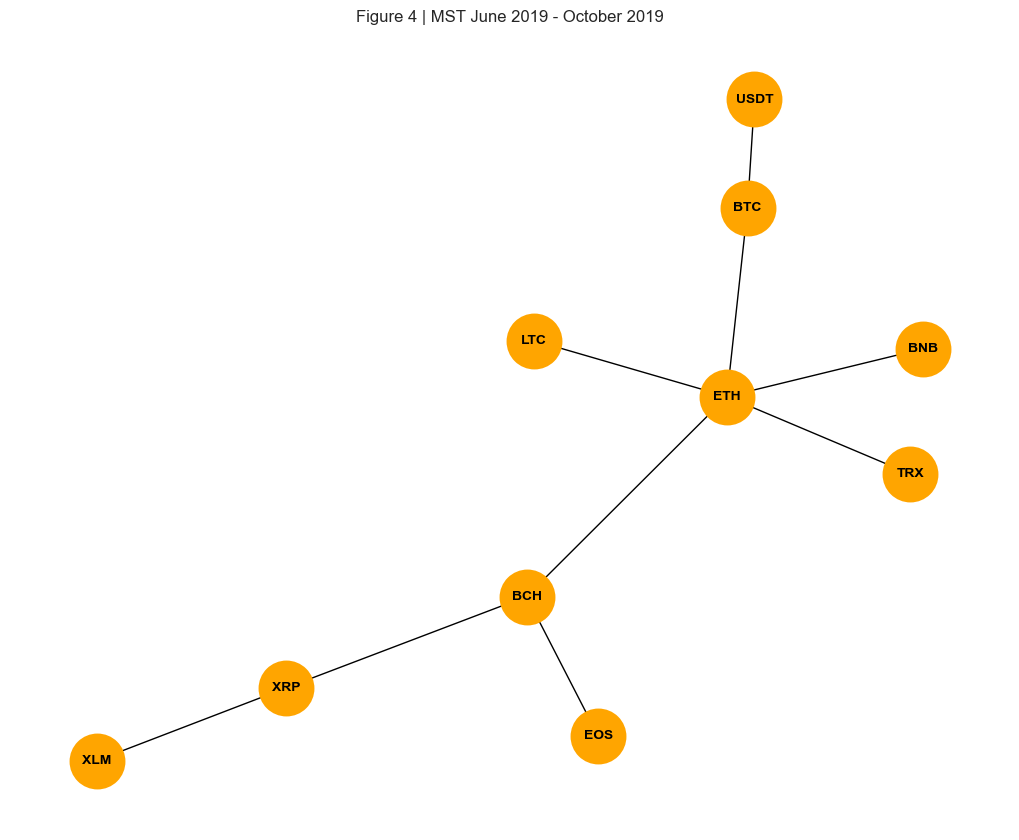

In [55]:
# --- Figure 3 | MST September 2017 - January 2018 (Speculative Bubble) ---
df_bubble    = df_returns.loc['2017-09-14':'2018-01-31']
corr_bubble  = df_bubble.corr()
dist_bubble  = np.sqrt(2 * (1 - corr_bubble))

G          = nx.from_pandas_adjacency(dist_bubble)
mst_bubble = nx.minimum_spanning_tree(G, weight='weight')

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(mst_bubble, seed=42)
nx.draw(mst_bubble, pos, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 3 | MST September 2017 - January 2018', fontsize=12)
plt.tight_layout()
plt.show()

# --- Figure 4 | MST June 2019 - October 2019 (Stable Period) ---
df_stable   = df_returns.loc['2019-06-01':'2019-10-17']
corr_stable = df_stable.corr()
dist_stable = np.sqrt(2 * (1 - corr_stable))

G2         = nx.from_pandas_adjacency(dist_stable)
mst_stable = nx.minimum_spanning_tree(G2, weight='weight')

plt.figure(figsize=(10, 8))
pos2 = nx.spring_layout(mst_stable, seed=42)
nx.draw(mst_stable, pos2, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 4 | MST June 2019 - October 2019', fontsize=12)
plt.tight_layout()
plt.show()

---
## Sel 6 — Fungsi Pembantu (Helper Functions)

Implementasi:
- **RMT Filter**: penyaringan noise matriks korelasi via Random Matrix Theory
- **MST Distance Matrix**: konversi korelasi ke jarak
- **Eigenvector Centrality**: sentralitas node dalam jaringan
- **VaR**, **Max Drawdown**, **Rachev Ratio**: metrik risiko

In [56]:
def apply_rmt_filter(returns_data):
    """Filter noise dari matriks korelasi menggunakan Random Matrix Theory (Marcenko-Pastur)."""
    if isinstance(returns_data, pd.DataFrame):
        data = returns_data.values
    else:
        data = returns_data
    T, N = data.shape
    Q    = T / N
    C    = np.corrcoef(data.T)

    eigenvalues, eigenvectors = eigh(C)
    eigenvalues  = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]

    lambda_plus      = 1 + (1/Q) + 2*np.sqrt(1/Q)   # Marcenko-Pastur upper bound
    significant_mask = eigenvalues > lambda_plus
    Lambda_filtered  = np.diag(np.where(significant_mask, eigenvalues, 0))
    C_filtered       = eigenvectors @ Lambda_filtered @ eigenvectors.T
    return C_filtered


def build_mst(correlation_matrix):
    """Konversi matriks korelasi ke matriks jarak untuk MST."""
    distance_matrix = np.sqrt(2 - 2 * correlation_matrix)
    np.fill_diagonal(distance_matrix, 0)
    return distance_matrix


def compute_eigenvector_centrality(distance_matrix):
    """Hitung sentralitas eigenvector dari matriks jarak."""
    adjacency = 1 / (distance_matrix + 1e-8)
    np.fill_diagonal(adjacency, 0)
    eigenvalues, eigenvectors = eigh(adjacency)
    principal_eigenvector = np.abs(eigenvectors[:, -1])
    centrality = principal_eigenvector / principal_eigenvector.sum()
    return centrality


def calculate_var(returns, confidence=0.95):
    """Hitung Value at Risk (VaR) pada tingkat kepercayaan tertentu."""
    return np.percentile(returns, (1 - confidence) * 100)


def calculate_rachev_ratio(returns, alpha=0.10):
    """Hitung Rachev Ratio: CVaR_upper / CVaR_lower pada level alpha."""
    threshold_upper = np.percentile(returns, (1 - alpha) * 100)
    threshold_lower = np.percentile(returns, alpha * 100)
    cvar_upper = returns[returns >= threshold_upper].mean()
    cvar_lower = abs(returns[returns <= threshold_lower].mean())
    return cvar_upper / cvar_lower if cvar_lower > 0 else 0


def calculate_max_drawdown(cumulative_returns):
    """Hitung Maximum Drawdown dari seri return kumulatif."""
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdown    = (cumulative_returns - running_max) / running_max
    return drawdown.min()


print("Helper functions defined successfully!")

Helper functions defined successfully!


---
## Sel New — Analisis Dinamika MST (Figure 5)

Rolling window untuk menghitung **Max Link Distance** dan **Residuality** MST sepanjang waktu.

Menghitung dinamika MST (rolling window=120)...


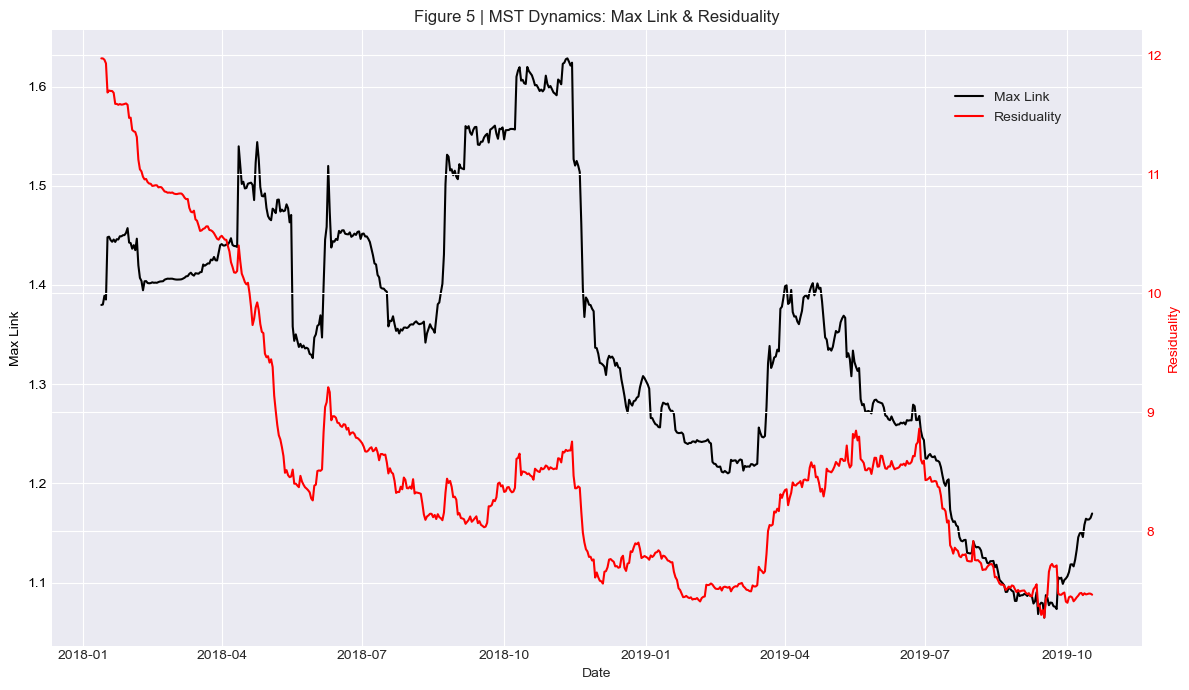

In [57]:
def calculate_rolling_mst_metrics(returns_df, window=120):
    """Hitung dinamika MST dengan rolling window."""
    dates         = returns_df.index[window:]
    max_links     = []
    residualities = []

    for i in range(window, len(returns_df)):
        window_data  = returns_df.iloc[i - window:i]
        corr_f       = apply_rmt_filter(window_data)
        mst_weights  = build_mst(corr_f)
        max_links.append(np.max(mst_weights))
        residualities.append(np.sum(mst_weights) / (returns_df.shape[1] - 1))

    return pd.DataFrame(
        {'Max Link': max_links, 'Residuality': residualities},
        index=dates
    )


print("Menghitung dinamika MST (rolling window=120)...")
mst_dyn = calculate_rolling_mst_metrics(df_returns)

# Visualisasi dengan dual axis
fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.set_xlabel('Date')
ax1.set_ylabel('Max Link', color='black')
ax1.plot(mst_dyn.index, mst_dyn['Max Link'], color='black', label='Max Link')
ax1.tick_params(axis='y', labelcolor='black')

ax2 = ax1.twinx()
ax2.set_ylabel('Residuality', color='red')
ax2.plot(mst_dyn.index, mst_dyn['Residuality'], color='red', label='Residuality')
ax2.tick_params(axis='y', labelcolor='red')

fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.title('Figure 5 | MST Dynamics: Max Link & Residuality')
plt.tight_layout()
plt.show()

---
## Sel 7 — Implementasi Strategi Portofolio

Semua strategi mewarisi kelas `PortfolioStrategy`. Model **AGGP v4** adalah model usulan yang menggabungkan EW (defensif) dan NW γ=1.0 (agresif) secara adaptif.

| Fix | Masalah v3 | Solusi v4 |
|-----|-----------|----------|
| Fix D | Komponen defensif GMV sensitif estimation error | Ganti ke **EW** yang lebih robust |
| Fix E | Threshold τ=0.25 terlalu kaku | Optimasi **stress_threshold = 0.15** |
| Fix F | Paparan NW kurang maksimal | Tingkatkan **gamma_max = 0.95** |

In [58]:
# ── Base Class ────────────────────────────────────────────────────────────────
class PortfolioStrategy:
    def __init__(self, name):
        self.name            = name
        self.weights_history = []
        self.returns_history = []

    def get_weights(self, returns_data):
        raise NotImplementedError


# ── 1. Equally Weighted ───────────────────────────────────────────────────────
class EquallyWeighted(PortfolioStrategy):
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        return np.ones(n) / n


# ── 2. Classical Markowitz ────────────────────────────────────────────────────
class ClassicalMarkowitz(PortfolioStrategy):
    """Optimasi Mean-Variance tradisional (minimasi varians portofolio)."""
    def get_weights(self, returns_data):
        n  = returns_data.shape[1]
        mu = returns_data.mean().values
        S  = returns_data.cov().values
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n) / n,
                       method='SLSQP', bounds=[(0, 1)] * n,
                       constraints=constraints)
        return res.x if res.success else np.ones(n) / n


# ── 3. Glasso Markowitz ───────────────────────────────────────────────────────
class GlassoMarkowitz(PortfolioStrategy):
    """Markowitz dengan matriks kovarians yang diestimasi via Graphical Lasso."""
    def get_weights(self, returns_data):
        n  = returns_data.shape[1]
        mu = returns_data.mean().values
        try:
            glasso = GraphicalLassoCV()
            glasso.fit(returns_data.values)
            S = glasso.covariance_
        except Exception:
            S = returns_data.cov().values
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n) / n,
                       method='SLSQP', bounds=[(0, 1)] * n,
                       constraints=constraints)
        return res.x if res.success else np.ones(n) / n


# ── 4. Network Markowitz ──────────────────────────────────────────────────────
class NetworkMarkowitz(PortfolioStrategy):
    """Network Markowitz: RMT + MST + penalti sentralitas eigenvector."""
    def __init__(self, name="Network Markowitz", gamma=0):
        super().__init__(name)
        self.gamma = gamma

    def get_weights(self, returns_data):
        n   = returns_data.shape[1]
        mu  = returns_data.mean().values
        sig = returns_data.std().values
        Cf   = apply_rmt_filter(returns_data)
        dist = build_mst(Cf)
        cent = compute_eigenvector_centrality(dist)
        Sf   = np.outer(sig, sig) * Cf
        objective   = lambda w: w @ Sf @ w + self.gamma * np.sum(cent * w)
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n) / n,
                       method='SLSQP', bounds=[(0, 1)] * n,
                       constraints=constraints)
        return res.x if res.success else np.ones(n) / n


# ── 5. Adaptive Graph-Gated Portfolio (AGGP v4) ───────────────────────────────
class AdaptiveGraphPortfolio(PortfolioStrategy):
    """
    AGGP v4: Perpaduan EW (Defensif) dan NW gamma=1.0 (Agresif).

    Mekanisme:
      - avg_pcorr >= stress_threshold  ->  gamma_t = gamma_min  ->  Dominan EW
      - avg_pcorr <  stress_threshold  ->  gamma_t blended      ->  Dominan NW
    """
    def __init__(self, name="AGGP v4", stress_threshold=0.15,
                 gamma_min=0.1, gamma_max=0.95):
        super().__init__(name)
        self.stress_threshold = stress_threshold
        self.gamma_min        = gamma_min
        self.gamma_max        = gamma_max

    def get_weights(self, returns_data):
        n   = returns_data.shape[1]
        mu  = returns_data.mean().values
        sig = returns_data.std().values

        # --- Sensor: Estimasi presisi via Graphical Lasso ---
        try:
            glasso = GraphicalLassoCV(cv=3)
            glasso.fit(returns_data.values)
            Pf = glasso.precision_
        except Exception:
            Cf = apply_rmt_filter(returns_data)
            Pf = np.linalg.pinv(np.outer(sig, sig) * Cf)

        # --- Sensor: Partial Correlation (proper) ---
        D_inv     = 1.0 / np.sqrt(np.diag(Pf))
        P_corr    = -Pf * np.outer(D_inv, D_inv)
        np.fill_diagonal(P_corr, 0.0)
        mask      = ~np.eye(n, dtype=bool)
        avg_pcorr = np.clip(np.mean(np.abs(P_corr[mask])), 0.0, 1.0)

        # --- Gating: threshold switching + soft blending ---
        if avg_pcorr >= self.stress_threshold:
            gamma_t = self.gamma_min
        else:
            ratio   = avg_pcorr / self.stress_threshold
            gamma_t = self.gamma_max * (1.0 - ratio)
            gamma_t = np.clip(gamma_t, self.gamma_min, self.gamma_max)

        # --- Komponen Agresif: NW gamma=1.0 ---
        Cf_rmt = apply_rmt_filter(returns_data)
        dist   = build_mst(Cf_rmt)
        cent   = compute_eigenvector_centrality(dist)
        Sf_nw  = np.outer(sig, sig) * Cf_rmt
        obj_nw  = lambda w: w @ Sf_nw @ w + 1.0 * np.sum(cent * w)
        cons_nw = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res_nw = minimize(obj_nw, np.ones(n) / n, method='SLSQP',
                          bounds=[(0, 1)] * n, constraints=cons_nw)
        w_net  = res_nw.x if res_nw.success else np.ones(n) / n

        # --- Komponen Defensif: Equally Weighted ---
        w_def = np.ones(n) / n

        # --- Blending Adaptif ---
        return (1.0 - gamma_t) * w_def + gamma_t * w_net


print("Semua kelas strategi berhasil didefinisikan!")

Semua kelas strategi berhasil didefinisikan!


---
## Sel 8 — Framework Backtesting

Rolling window backtest dengan:
- **Window**: 120 hari
- **Rebalance**: setiap 7 hari
- **Transaction cost**: 0.1% (10 bps)

In [59]:
def backtest_strategy(strategy, df_returns, window_size=120,
                      rebalance_freq=7, transaction_cost=0.001):
    """Simulasi backtest dengan rolling window dan biaya transaksi."""
    portfolio_returns = []
    dates = []

    for i in range(window_size, len(df_returns), rebalance_freq):
        train    = df_returns.iloc[i - window_size:i]
        w        = strategy.get_weights(train)
        test_end  = min(i + rebalance_freq, len(df_returns))
        test_data = df_returns.iloc[i:test_end]

        for j in range(len(test_data)):
            daily_ret = np.dot(w, test_data.iloc[j].values)
            if j == 0 and len(portfolio_returns) > 0:
                daily_ret -= transaction_cost
            portfolio_returns.append(daily_ret)
            dates.append(test_data.index[j])

    res_df = pd.DataFrame({'date': dates, 'return': portfolio_returns})
    res_df['cumulative_return'] = (1 + res_df['return']).cumprod()

    return {
        'strategy':           strategy.name,
        'returns':            np.array(portfolio_returns),
        'cumulative_returns': res_df['cumulative_return'].values,
        'results_df':         res_df
    }


print("Fungsi backtest_strategy siap digunakan!")

Fungsi backtest_strategy siap digunakan!


---
## Sel 9 — Eksekusi Backtesting

Menjalankan simulasi untuk semua strategi.

In [60]:
# --- Inisialisasi strategi ---
strategies = [
    EquallyWeighted("EW"),
    ClassicalMarkowitz("CM"),
    GlassoMarkowitz("GM"),
    NetworkMarkowitz("NW (gamma=0)",   gamma=0),
    NetworkMarkowitz("NW (gamma=1.0)", gamma=1.0),   # Best performer Giudici et al.
    AdaptiveGraphPortfolio(
        "AGGP v4",
        stress_threshold=0.15,
        gamma_min=0.1,
        gamma_max=0.95
    ),
]

# --- Eksekusi backtest ---
results = {}
for strat in strategies:
    print(f"Backtesting: {strat.name}...")
    results[strat.name] = backtest_strategy(strat, df_returns)
    final_cum = (results[strat.name]['cumulative_returns'][-1] - 1) * 100
    print(f"  -> Done. Final Cumulative Return: {final_cum:.2f}%")

print("\nSemua backtest selesai!")

Backtesting: EW...
  -> Done. Final Cumulative Return: -88.49%
Backtesting: CM...
  -> Done. Final Cumulative Return: -61.56%
Backtesting: GM...
  -> Done. Final Cumulative Return: -67.05%
Backtesting: NW (gamma=0)...
  -> Done. Final Cumulative Return: -67.56%
Backtesting: NW (gamma=1.0)...
  -> Done. Final Cumulative Return: -48.16%
Backtesting: AGGP v4...
  -> Done. Final Cumulative Return: -75.45%

Semua backtest selesai!


---
## Sel 10 — Analisis Performa Periodik (Table 2)

Performa kumulatif yang disampel setiap periode (Januari, Mei, September).

In [61]:
target_dates = [
    '2018-01-31', '2018-05-31', '2018-09-30',
    '2019-01-31', '2019-05-31', '2019-09-30'
]

table2_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for td in target_dates:
        idx     = df_res.index.searchsorted(pd.Timestamp(td))
        idx     = min(idx, len(df_res) - 1)
        cum_ret = (df_res['cumulative_return'].iloc[idx] - 1) * 100
        row[td] = round(cum_ret, 2)
    table2_rows.append(row)

table2 = pd.DataFrame(table2_rows).set_index('Strategy')
table2.columns = ['Jan-18', 'May-18', 'Sep-18', 'Jan-19', 'May-19', 'Sep-19']

print("TABLE 2 | Cumulative Profits and Losses (%)")
print(table2.to_string())

TABLE 2 | Cumulative Profits and Losses (%)
                Jan-18  May-18  Sep-18  Jan-19  May-19  Sep-19
Strategy                                                      
EW              -35.53  -58.96  -77.02  -89.67  -77.88  -88.82
CM              -34.32  -57.88  -59.66  -68.22  -55.67  -62.16
GM              -33.86  -60.11  -61.90  -73.12  -62.49  -67.53
NW (gamma=0)    -41.59  -62.30  -63.81  -71.79  -61.83  -68.05
NW (gamma=1.0)  -39.09  -51.94  -53.57  -54.17  -41.10  -48.05
AGGP v4         -37.33  -54.08  -66.91  -78.59  -62.70  -75.88


---
## Sel 11 — Visualisasi Performa Kumulatif (Figure 6)

Evolusi nilai portofolio dengan asumsi investasi awal **100 USD**.

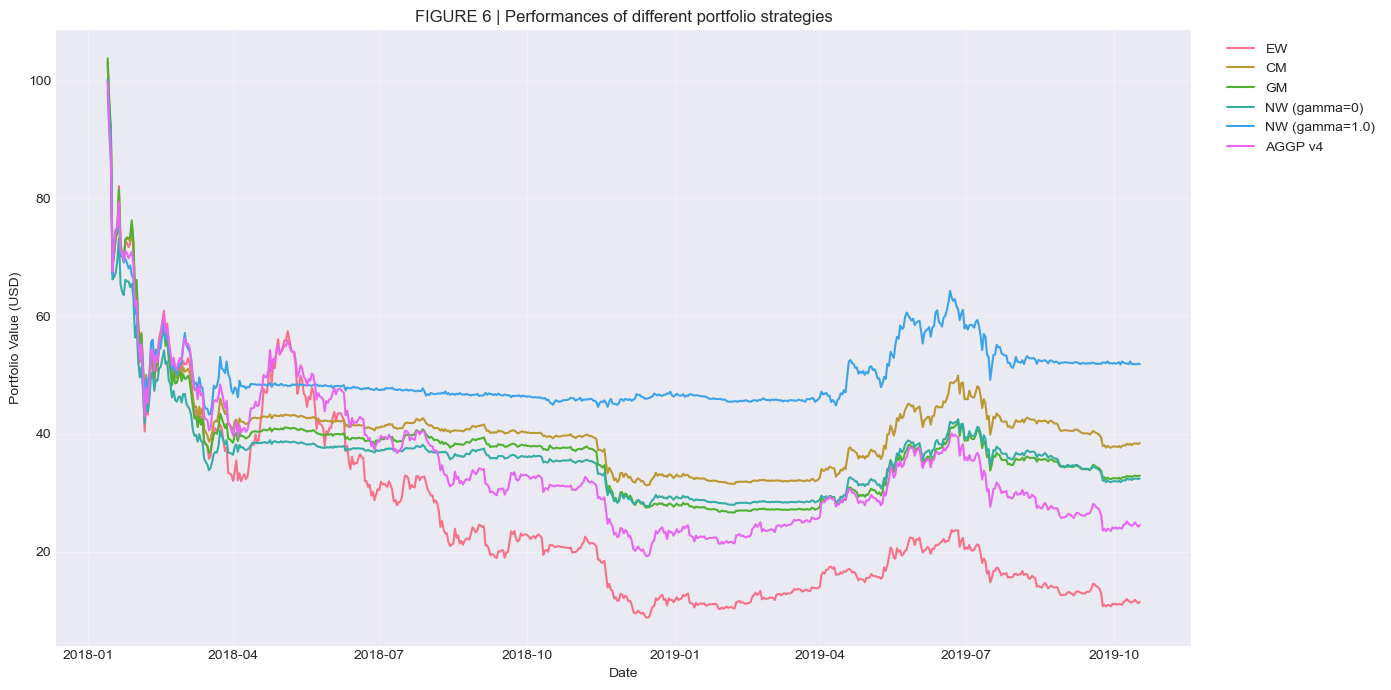

In [62]:
plt.figure(figsize=(14, 7))
for name, res in results.items():
    plt.plot(
        res['results_df']['date'],
        res['cumulative_returns'] * 100,
        label=name
    )

plt.title('FIGURE 6 | Performances of different portfolio strategies')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Sel 12 — Analisis Risiko Periodik: VaR 95% (Table 3)

Value at Risk (VaR) untuk jendela 4 bulan, nilai absolut × 100.

In [63]:
def compute_periodic_metric(results_dict, target_dates, metric_fn, window_days=120):
    """Hitung metrik risiko secara periodik pada setiap tanggal sampling."""
    rows = []
    for strat_name, res in results_dict.items():
        df_res = res['results_df'].set_index('date')
        row    = {'Strategy': strat_name}
        for td in target_dates:
            idx_end   = df_res.index.searchsorted(pd.Timestamp(td))
            idx_end   = min(idx_end, len(df_res) - 1)
            idx_start = max(idx_end - window_days, 0)
            segment   = df_res['return'].iloc[idx_start:idx_end + 1].values
            row[td]   = round(metric_fn(segment), 4)
        rows.append(row)
    return pd.DataFrame(rows).set_index('Strategy')


# VaR 95% (nilai absolut × 100)
table3 = compute_periodic_metric(
    results, target_dates,
    lambda r: abs(calculate_var(r, confidence=0.95)) * 100
)
table3.columns = ['Jan-18', 'May-18', 'Sep-18', 'Jan-19', 'May-19', 'Sep-19']

print("TABLE 3 | Value at Risk 95% (4-month window, absolute × 100)")
print(table3.to_string())

TABLE 3 | Value at Risk 95% (4-month window, absolute × 100)
                 Jan-18  May-18  Sep-18  Jan-19  May-19  Sep-19
Strategy                                                       
EW              13.7904  9.5022  6.5585  9.5350  3.6718  8.2776
CM              12.8261  5.7940  1.0018  1.7267  1.6995  3.8440
GM              13.4648  5.9247  1.1860  2.4594  1.8105  4.3028
NW (gamma=0)    12.4709  5.5937  1.1532  1.8485  1.5132  4.0287
NW (gamma=1.0)  10.3486  5.6038  0.7126  0.9577  1.2792  3.0595
AGGP v4         11.8260  6.4114  3.6864  5.7556  2.4835  5.9744


---
## Sel 13 — Analisis Risk-Adjusted Return: Sharpe Ratio (Table 4)

In [64]:
# Sharpe Ratio = Mean / Std
table4 = compute_periodic_metric(
    results, target_dates,
    lambda r: np.mean(r) / np.std(r) if np.std(r) > 0 else 0
)
table4.columns = ['Jan-18', 'May-18', 'Sep-18', 'Jan-19', 'May-19', 'Sep-19']

print("TABLE 4 | Sharpe Ratio (4-month window)")
print(table4.to_string())

TABLE 4 | Sharpe Ratio (4-month window)
                Jan-18  May-18  Sep-18  Jan-19  May-19  Sep-19
Strategy                                                      
EW             -0.2532 -0.0387 -0.0992 -0.1245  0.1955 -0.1294
CM             -0.2508 -0.0880 -0.0623 -0.1497  0.1886 -0.0605
GM             -0.2355 -0.0938 -0.0583 -0.1873  0.1743 -0.0531
NW (gamma=0)   -0.3442 -0.0942 -0.0572 -0.1535  0.1833 -0.0708
NW (gamma=1.0) -0.3849 -0.0426 -0.0692 -0.0145  0.1556 -0.0516
AGGP v4        -0.3288 -0.0399 -0.1058 -0.1195  0.2125 -0.1181


---
## Sel 14 — Analisis Tail-Risk: Rachev Ratio (Table 5)

In [65]:
# Rachev Ratio = CVaR_upper(10%) / CVaR_lower(10%)
table5 = compute_periodic_metric(
    results, target_dates,
    lambda r: calculate_rachev_ratio(r, alpha=0.10)
)
table5.columns = ['Jan-18', 'May-18', 'Sep-18', 'Jan-19', 'May-19', 'Sep-19']

print("TABLE 5 | Rachev Ratio (4-month window, alpha=10%)")
print(table5.to_string())

TABLE 5 | Rachev Ratio (4-month window, alpha=10%)
                Jan-18  May-18  Sep-18  Jan-19  May-19  Sep-19
Strategy                                                      
EW              0.3926  0.8936  0.8062  0.7200  1.7375  0.5381
CM              0.3969  0.7673  0.7865  0.6506  1.9847  0.7510
GM              0.4126  0.7528  0.7760  0.5600  1.6963  0.7353
NW (gamma=0)    0.2494  0.7707  0.7824  0.6389  2.0798  0.7820
NW (gamma=1.0)  0.3488  1.0185  0.8170  1.0171  2.1511  0.8614
AGGP v4         0.3761  0.8795  0.7945  0.7447  1.7342  0.5741


---
## Sel 15 — Analisis Fase Pasar (Table 6)

Performa AGGP v4 dipetakan ke tiga fase pasar: **Bearish**, **Recovery**, dan **Stable**.

- **Bearish** (avg_pcorr ≥ τ): γ_t = γ_min = 0.1 → dominan EW (defensif)
- **Recovery/Stable** (avg_pcorr < τ): γ_t naik hingga 0.95 → dominan NW (agresif)

In [66]:
# Definisi Fase Pasar
fase_pasar = {
    'Bearish':  ('2018-01-01', '2019-03-31'),
    'Recovery': ('2019-04-01', '2019-06-30'),
    'Stable':   ('2019-07-01', '2019-10-17')
}

phase_rows_sr = []
phase_rows_rr = []

for strat_name, res in results.items():
    df_res  = res['results_df'].set_index('date')
    row_sr  = {'Strategy': strat_name}
    row_rr  = {'Strategy': strat_name}

    for phase, (start, end) in fase_pasar.items():
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 0:
            sr = np.mean(segment) / np.std(segment) if np.std(segment) > 0 else 0
            rr = calculate_rachev_ratio(segment, alpha=0.10)
        else:
            sr, rr = np.nan, np.nan
        row_sr[phase] = round(sr, 4)
        row_rr[phase] = round(rr, 4)

    phase_rows_sr.append(row_sr)
    phase_rows_rr.append(row_rr)

table6_sr = pd.DataFrame(phase_rows_sr).set_index('Strategy')
table6_rr = pd.DataFrame(phase_rows_rr).set_index('Strategy')

print("TABLE 6 | Market Phase Performance")
print("\nPanel A: Sharpe Ratio")
print(table6_sr.to_string())
print("\nPanel B: Rachev Ratio (alpha=10%)")
print(table6_rr.to_string())

TABLE 6 | Market Phase Performance

Panel A: Sharpe Ratio
                Bearish  Recovery  Stable
Strategy                                 
EW              -0.0726    0.1286 -0.1301
CM              -0.0923    0.1844 -0.1022
GM              -0.0991    0.1732 -0.0950
NW (gamma=0)    -0.1072    0.1763 -0.1095
NW (gamma=1.0)  -0.0685    0.1359 -0.0628
AGGP v4         -0.0788    0.1441 -0.1236

Panel B: Rachev Ratio (alpha=10%)
                Bearish  Recovery  Stable
Strategy                                 
EW               0.7933    1.2168  0.5712
CM               0.6463    1.2463  0.7523
GM               0.6275    1.1627  0.7477
NW (gamma=0)     0.5982    1.2883  0.7615
NW (gamma=1.0)   0.7244    1.4069  0.8656
AGGP v4          0.7708    1.1452  0.6028
